In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import os

import spatialtools as st

figure_dir = "figures/revision/figure-3"
figure_dir_2 = "figures/revision/supplement"
st.utils.setup_plotting(figure_dir)
st.utils.setup_plotting(figure_dir_2)

import matplotlib.pyplot as plt
import nichepca as npc
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
import seaborn as sns
from spatialtools.distances import distance_matrix
from spatialtools.nhood_analysis import (
    compute_nhood_composition,
    compute_nhood_expression,
)
from spatialtools.stats import (
    wilcoxon_significance,
)

from spatial_tcr.tcr import get_tcr_genes

## Load data

In [19]:
data_dir = "data/xenium/processed"
path = os.path.join(data_dir, "08.1-kidney_tcr_clonal_clusters.h5ad")
adata = sc.read_h5ad(path)
adata = adata[adata.obs["condition"] == "ANCA"].copy()
adata.X = adata.layers["counts"].copy()
adata

AnnData object with n_obs × n_vars = 389390 × 431
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate', 'cell_type_l1.1', 'av_

In [20]:
cc_key = "avbv_cluster_filtered"

In [21]:
adata.obs["is_avbv_cluster"] = adata.obs[cc_key].notna().astype(str)
adata.obs.loc[adata.obs[cc_key].isna(), "is_avbv_cluster"] = None


# prepare other T cell column that excludes all T cells in clusters
adata.obs["ct_outside_cluster"] = adata.obs["cell_type_l2"].copy()
adata.obs.loc[adata.obs[cc_key].notna(), "ct_outside_cluster"] = None

## Construct neighborhood graph

In [22]:
npc.gc.construct_multi_sample_graph(
    adata,
    sample_key="sample",
    obsm_key="spatial",
    radius=25,
    remove_self_loops=True,
    verbose=False,
)

  0%|          | 0/10 [00:00<?, ?it/s]

## Compute cell type composition

In [23]:
ad_nhood_tclonal = compute_nhood_composition(
    adata, obs_key="is_avbv_cluster", comp_key="cell_type_l2"
)
ad_nhood_not_tclonal = compute_nhood_composition(
    adata, obs_key="ct_outside_cluster", comp_key="cell_type_l2"
)
tcell_keys = [
    "CD4+",
    # "TFH",
    "Tregs",
    "MAIT",
    "CD8+",
    "NKT-like",
]
ad_nhood_tcells_not_clonal = ad_nhood_not_tclonal[
    ad_nhood_not_tclonal.obs["ct_outside_cluster"].isin(tcell_keys)
].copy()

In [24]:
# merge the expression
var_names = ad_nhood_tclonal.var_names
ad_merged = sc.AnnData(
    X=np.concatenate(
        [
            ad_nhood_tclonal.X,
            ad_nhood_tcells_not_clonal[:, var_names].X,
        ],
        axis=0,
    ),
    var=ad_nhood_tclonal.var,
    obs=pd.concat([ad_nhood_tclonal.obs, ad_nhood_tcells_not_clonal.obs], axis=0),
)
ad_merged.obs["group"] = "cluster\nnhood."
ad_merged.obs.loc[ad_nhood_tcells_not_clonal.obs_names, "group"] = "non-cluster\nnhood."

In [25]:
ct_comp_merged = ad_merged.to_df()
ct_comp_merged = pd.concat([ct_comp_merged, ad_merged.obs[["group"]]], axis=1)

In [26]:
from statsmodels.stats.multitest import multipletests

group_key = "group"

ct_comp_merged_normalized = ct_comp_merged.copy()
ct_cols = [c for c in ct_comp_merged_normalized.columns if c != group_key]
ct_comp_merged_normalized[ct_cols] = ct_comp_merged_normalized[ct_cols].div(
    ct_comp_merged_normalized[ct_cols].sum(axis=1), axis=0
)

p_values = {}
for ct in ct_cols:
    p_values[ct] = wilcoxon_significance(
        ct_comp_merged_normalized, ct, group_key=group_key
    )

# perform multiple testing correction
p_values_corrected = multipletests(list(p_values.values()), method="fdr_bh")[1]
p_values = dict(zip(p_values.keys(), p_values_corrected))


mean_comp = ct_comp_merged_normalized.groupby(group_key).mean()
ratios = mean_comp.iloc[0] / mean_comp.iloc[1]
ratios = ratios.sort_values(ascending=True)
mean_comp = mean_comp[ratios.index]
# mean_comp.index = ["TFH\nCXCL13+", "TFH\nCXCL13-"]
mean_comp

,PapE,NEU,POD,PEC,PC,MC,DCT,pDC,PT,CNT,...,cDC,gdT,unknown,MDC,MAIT,B,CD4+,CD8+,cycMNP,Tregs
group,,,,,,,,,,,,,,,,,,,,,
cluster\nnhood.,0.000000,0.00000,0.000682,0.000908,0.002715,0.000289,0.002452,0.000084,0.063809,0.009398,...,0.001985,0.003135,0.016791,0.131044,0.009515,0.075384,0.112351,0.075758,0.006774,0.018978
non-cluster\nnhood.,0.000086,0.00008,0.004170,0.004889,0.009823,0.000974,0.008076,0.000199,0.115473,0.016438,...,0.001737,0.002515,0.011454,0.086316,0.006211,0.047999,0.067889,0.043513,0.003526,0.008317


/tmp/ipykernel_360081/967238776.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_comp_per_group_norm["other"] = 1 - agg_comp_per_group_norm.sum(axis=1)


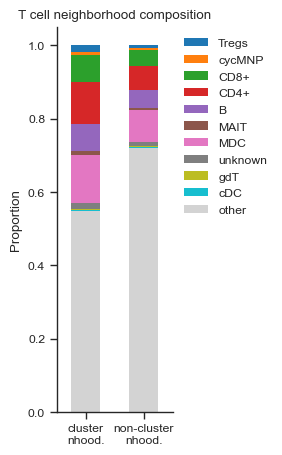

In [27]:
sns.set_theme(style="ticks", context="paper")

agg_comp_per_group_norm = mean_comp[mean_comp.columns[-10::]]
agg_comp_per_group_norm["other"] = 1 - agg_comp_per_group_norm.sum(axis=1)
# move other columns to the front
agg_comp_per_group_norm = agg_comp_per_group_norm[
    ["other"] + list(agg_comp_per_group_norm.columns[:-1])
]

celltypes = agg_comp_per_group_norm.columns
palette = sns.color_palette("tab10", len(celltypes))
palette = {ct: palette[i] for i, ct in enumerate(celltypes[::-1])}
palette["other"] = "lightgray"

fig, ax = plt.subplots(figsize=(1.5, 5))
agg_comp_per_group_norm.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[palette[ct] for ct in agg_comp_per_group_norm.columns],
    linewidth=0,
)

ax.set_title("T cell neighborhood composition")
ax.set_ylabel("Proportion")
ax.set_xlabel("")
# ax.get_legend().remove()
# ax.legend(
#     bbox_to_anchor=(0.5, -0.2),
#     loc="upper center",
#     ncol=7,
#     bbox_transform=ax.transAxes,
#     frameon=False,
# )
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1, 1), frameon=False, ncol=1)
sns.despine(ax=ax, right=True, top=True)

# set x-axis labels to ANCA and Control
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")
plt.show()
# plt.tight_layout()

In [28]:
nhood_ct_comp_melted = pd.melt(
    mean_comp.reset_index(),
    id_vars="group",
    var_name="cell_type",
    value_name="proportion",
)
nhood_ct_comp_melted.columns = ["group", "cell_type", "prop"]

In [29]:
adata.obs.cell_type_l2.value_counts()

cell_type_l2
PT          80002
FIB         69927
Mac         49222
EC          31755
TAL         30850
MDC         20645
VSM/P       12812
PC          12616
IC          11990
CNT          9685
CD4+         9125
CD8+         6430
DCT          6275
PL           5895
B            5777
DTL          4720
POD          4454
PEC          3435
glom. EC     3305
unknown      1722
NKT-like     1684
MC           1643
Tregs        1135
MAST         1048
MAIT          807
cycMNP        758
N             512
gdT           440
ATL           375
cDC           278
pDC            32
PapE           24
NEU            12
Name: count, dtype: int64

B: 6.886101218698728e-09


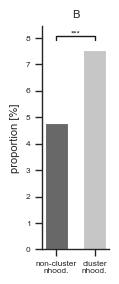

MDC: 3.86521870175129e-12


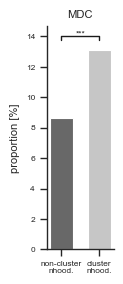

cDC: 0.034347524053165344


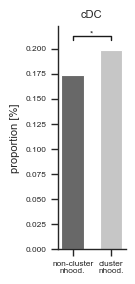

pDC: 0.8322826283668666


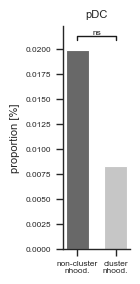

In [30]:
sns.set_theme(style="ticks", context="paper")

relevant_cts = mean_comp.columns[::-1][:11]

relevant_cts = ["B", "MDC", "cDC", "pDC"]

scaler = 0.58
for ct in relevant_cts:
    colors = sns.color_palette("Greys", n_colors=2)[::-1]

    plot_df = nhood_ct_comp_melted[nhood_ct_comp_melted["cell_type"] == ct]

    plot_df.loc[:, "prop"] = plot_df["prop"] * 100

    fig, ax = plt.subplots(figsize=(1.5 * scaler, 5 * scaler))
    sns.barplot(
        x="group",
        y="prop",
        hue="group",
        data=plot_df.iloc[::-1],
        ax=ax,
        palette=colors,
        width=0.6,
    )
    ax.set_title(f"{ct}", fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("proportion [%]", fontsize=8)

    # Add significance bar and star
    # Convert p-value to star notation
    # n_cells_clonal = ad_nhood_tclonal.obsm["ct_counts"].sum(axis=1).sum()
    # ct_cells_clonal = ad_nhood_tclonal.obsm["ct_counts"][ct].sum()
    # other_cells_clonal = n_cells_clonal - ct_cells_clonal

    # n_cells_nonclonal = ad_nhood_not_tclonal.obsm["ct_counts"].sum(axis=1).sum()
    # ct_cells_nonclonal = ad_nhood_not_tclonal.obsm["ct_counts"][ct].sum()
    # other_cells_nonclonal = n_cells_nonclonal - ct_cells_nonclonal
    # p_value = count_test(
    #     ct_cells_clonal, other_cells_clonal, ct_cells_nonclonal, other_cells_nonclonal
    # )
    p_value = p_values[ct]
    print(f"{ct}: {p_value}")
    if p_value < 0.001:
        stars = "***"
    elif p_value < 0.01:
        stars = "**"
    elif p_value < 0.05:
        stars = "*"
    else:
        stars = "ns"
    # Adjust the y-offset based on your data range:
    y_max = np.max(plot_df["prop"].values)
    y = y_max + 0.05 * (y_max)  # starting height of the line
    h = 0.02 * (y_max)  # height of the significance bar

    x1, x2 = 0, 1
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.0, c="k")
    ax.text(
        (x1 + x2) * 0.5, y + h, stars, ha="center", va="bottom", color="k", fontsize=6
    )

    # Add a bit more space at the top of the plot for significance annotation
    ax.set_ylim(top=y + h + 0.05 * y_max, bottom=0)
    ax.tick_params(axis="both", labelsize=6)

    sns.despine()
    # plt.tight_layout()
    plt.savefig(
        os.path.join(figure_dir, f"cc_nhood_comp_{ct}.pdf"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

## Analyze distance to APCs and compare for other t cells

In [31]:
# create col with t in clonal cluster, t outside clonal cluster and other cell type labels
adata.obs["tmp"] = adata.obs["cell_type_l2"].astype(str)
t_mask = adata.obs["cell_type_l2"].isin(tcell_keys)
adata.obs.loc[t_mask, "tmp"] = "other abT"
adata.obs.loc[adata.obs[cc_key].notna(), "tmp"] = "clustered abT"
# adata.obs["tmp"].value_counts()

In [32]:
dist_mat, dist_mat_per_sample, dists_combined = distance_matrix(
    adata, obs_key="tmp", sample_key="cc"
)

  0%|          | 0/28 [00:00<?, ?it/s]

In [33]:
apcs = ["B", "pDC", "cDC", "MDC"]
# dist_mat_relevant = dist_mat.loc[
#     ["other abT", "clustered abT"], apcs + ["other abT", "clustered abT"]
# ]
dist_mat_relevant = dist_mat.loc[["other abT", "clustered abT"]]
dist_mat_relevant

,other abT,FIB,IC,CNT,Mac,PC,MDC,EC,PT,DCT,...,gdT,ATL,POD,MC,glom. EC,N,cDC,pDC,PapE,NEU
cell_type,,,,,,,,,,,,,,,,,,,,,
other abT,0.000000,10.222607,69.620651,63.281035,10.830796,102.375389,17.151416,17.983290,22.510625,120.011174,...,136.594989,539.143606,165.912360,216.648721,169.075554,147.643563,202.333115,524.978086,551.089172,843.717409
clustered abT,8.293951,10.843906,80.609203,63.755729,9.954801,120.656697,12.480879,20.487257,30.587016,132.926933,...,93.346772,540.541147,171.259593,265.087147,203.317445,114.172032,124.848397,311.655846,525.343219,921.129441


### Bar plot

In [34]:
df = dist_mat_relevant.T.reset_index()
df["ratio"] = df["clustered abT"] / df["other abT"]
df = df.sort_values("ratio", ascending=True)
df.drop(columns=["ratio"], inplace=True)
display(df.head())


df = df.melt(id_vars="index", var_name="class")
mask = df["index"].isin(("other abT", "clustered abT"))
df = df[~mask].reset_index(drop=True)
df.head()

cell_type,index,other abT,clustered abT
18,clustered abT,235.684254,0.000000
13,B,35.555689,20.805296
27,pDC,524.978086,311.655846
26,cDC,202.333115,124.848397
20,gdT,136.594989,93.346772


,index,class,value
0,B,other abT,35.555689
1,pDC,other abT,524.978086
2,cDC,other abT,202.333115
3,gdT,other abT,136.594989
4,MDC,other abT,17.151416


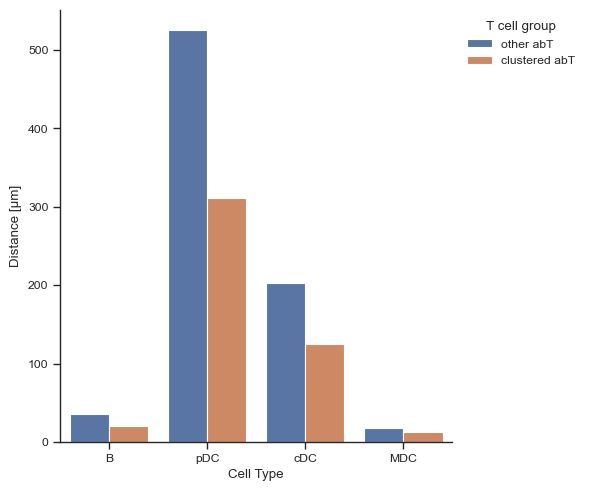

In [35]:
sns.set_theme(style="ticks", context="paper")
plt.figure(figsize=(6, 5))
mask = df["index"].isin(["cDC", "B", "MDC", "pDC"])
sns.barplot(
    data=df[mask],
    x="index",
    y="value",
    hue="class",
    # palette=["#ff8c8c", "#7fbfff"],
    # alpha=0.8,
    width=0.8,
)

plt.xticks(rotation=0, ha="center")
plt.xlabel("Cell Type")
plt.ylabel("Distance [µm]")
# plt.title("Distance Between Cell Types", pad=20)
plt.legend(
    title="T cell group", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False
)
sns.despine()
plt.tight_layout()

### Boxplot variant

In [36]:
df = dists_combined.drop(columns=["sample"])
# df["ratio"] = df["clustered abT"] / df["other abT"]
# df = df.sort_values("ratio", ascending=True)
# df.drop(columns=["ratio"], inplace=True)
df = df.melt(id_vars="cell_type", var_name="other_cell_type", value_name="value")
df = df[df["cell_type"].isin(["other abT", "clustered abT"])]
df = df[~df["other_cell_type"].isin(["other abT", "clustered abT"])]
df.dropna(inplace=True)
df

,cell_type,other_cell_type,value
389390,other abT,FIB,7.461670
389392,other abT,FIB,5.742859
389417,other abT,FIB,9.790359
389435,other abT,FIB,3.880469
389487,other abT,FIB,7.987012
...,...,...,...
11669940,other abT,NEU,1001.819444
11669951,other abT,NEU,707.912336
11669972,other abT,NEU,26.252451
11669974,other abT,NEU,183.541682


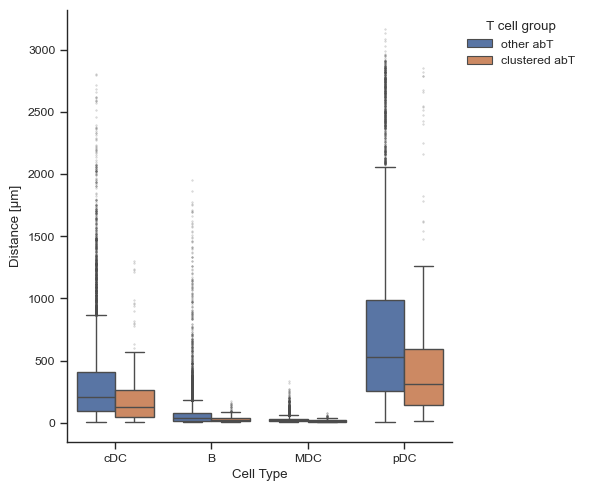

In [37]:
sns.set_theme(style="ticks", context="paper")
plt.figure(figsize=(6, 5))
mask = df["other_cell_type"].isin(["cDC", "B", "MDC", "pDC"])
sns.boxplot(
    data=df[mask],
    x="other_cell_type",
    y="value",
    hue="cell_type",
    # palette=["#ff8c8c", "#7fbfff"],
    # alpha=0.8,
    width=0.8,
    order=["cDC", "B", "MDC", "pDC"],
    fliersize=1,
    flierprops={"marker": ".", "alpha": 0.3},
)

plt.xticks(rotation=0, ha="center")
plt.xlabel("Cell Type")
plt.ylabel("Distance [µm]")
# plt.title("Distance Between Cell Types", pad=20)
plt.legend(
    title="T cell group", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False
)
sns.despine()
plt.tight_layout()

### Scatterplot

0.2054546855337836 3.081743239425769e-05
[np.float64(352.1449463763406), np.float64(76.95107622309442), np.float64(66.00259993500163), np.float64(253.79865503362416), np.float64(79.92450188745283), np.float64(118.06129846753832), np.float64(170.8324791880203), np.float64(400.0), np.float64(49.80550486237844), np.float64(166.53383665408364), np.float64(80.85547861303468), np.float64(48.00054998625035), np.float64(47.440063998400035), np.float64(23.600409989750258), np.float64(24.977875553111172), np.float64(28.17929551761206), np.float64(42.419439514012154), np.float64(36.3158421039474), np.float64(22.08994775130622), np.float64(21.781205469863252), np.float64(41.15597110072248), np.float64(27.804054898627534), np.float64(35.698357541061476), np.float64(22.431939201519963), np.float64(21.320466988325293), np.float64(20.151996200095), np.float64(20.11399715007125), np.float64(20.056998575035625)]
[<matplotlib.lines.Line2D object at 0x7d1e94e71090>, <matplotlib.lines.Line2D object at 0x7d

/tmp/ipykernel_360081/675437612.py:60: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 225)
/tmp/ipykernel_360081/675437612.py:61: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 225)


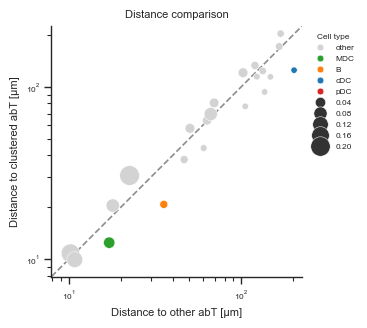

In [39]:
df = dist_mat_relevant.T.reset_index()
mask = df["index"].isin(["clustered abT", "other abT"])
df = df[~mask]

# mask = df["index"].isin(["cDC", "B", "MDC", "pDC"])
# df = df[mask]
palette = sns.color_palette("tab10")


# def mapper(x):
#     if x not in ["cDC", "B", "MDC", "pDC"]:
#         return "other"
#     else:
#         return x
relevant_cts = ["cDC", "B", "MDC", "pDC"]

# df["index"] = df["index"].astype(str).map(mapper)
color_map = dict(zip(relevant_cts, palette[: len(relevant_cts)]))
for ct in df["index"].unique():
    if ct not in color_map:
        color_map[ct] = "lightgray"


sns.set_theme(style="ticks", context="paper")
scaler = 0.75
fig, ax = plt.subplots(figsize=(5 * scaler, 5 * scaler))

ct_ratios = adata.obs["tmp"].value_counts(normalize=True)
# Scale the sizes based on cell type ratios, multiplied by 5000 to make them visible
max_size = 400
min_size = 20
max_ratio = max(ct_ratios.values)
min_ratio = min(ct_ratios.values)
print(max_ratio, min_ratio)
sizes = [
    (ct_ratios[ct] / max_ratio) * (max_size - min_size) + min_size for ct in df["index"]
]
print(sizes)
sizes = [ct_ratios[ct] for ct in df["index"]]

sns.scatterplot(
    df,
    x="other abT",
    y="clustered abT",
    hue="index",
    ax=ax,
    size=sizes,
    sizes=(20, 200),
    # alpha=0.8,
    # legend="brief",
    palette=color_map,
)

# Convert to log scale
ax.set_xscale("log")
ax.set_yscale("log")


# Add diagonal line
ax.set_xlim(0, 225)
ax.set_ylim(0, 225)

lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
ax.plot(lims, lims, "k--", alpha=0.5, zorder=0)  # black dashed line
ax.set_aspect("equal")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("Distance to other abT [µm]", fontsize=8)
ax.set_ylabel("Distance to clustered abT [µm]", fontsize=8)
ax.set_title("Distance comparison", fontsize=8)
ax.tick_params(axis="both", labelsize=6)

# Get the legend handles and labels
handles, labels = ax.get_legend_handles_labels()
print(handles)
print(labels)

# Create a new legend with only the color markers
new_handles = []
new_labels = []
seen_other = False
for h, l in zip(handles, labels):
    if l in relevant_cts:
        new_handles.append(h)
        new_labels.append(l)
    elif not seen_other:
        new_handles.append(h)
        new_labels.append("other")
        seen_other = True

# also add the size legend part
for h, l in zip(handles, labels):
    try:
        float(l)
        new_handles.append(h)
        new_labels.append(l)
    except (ValueError, TypeError):
        pass

legend = ax.legend(
    new_handles,  # Only keep the color markers
    new_labels,  # Only keep the labels
    title="Cell type",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
)
sns.despine()
plt.tight_layout()
plt.savefig(
    os.path.join(figure_dir, "distance_comparison.pdf"), dpi=300, bbox_inches="tight"
)
plt.show()

## Compute neighborhood expression

In [22]:
ad_nhood_tclonal = compute_nhood_expression(
    adata, obs_key="is_avbv_cluster", construct_graph=False, layer="counts"
)
ad_nhood_not_tclonal = compute_nhood_expression(
    adata, obs_key="ct_outside_cluster", construct_graph=False, layer="counts"
)
tcell_keys = [
    "CD4+",
    # "TFH",
    "Tregs",
    "MAIT",
    "CD8+",
    "NKT-like",
]
print(adata[adata.obs["cell_type_l2"].isin(tcell_keys)].shape[0])
ad_nhood_tcells_not_clonal = ad_nhood_not_tclonal[
    ad_nhood_not_tclonal.obs["ct_outside_cluster"].isin(tcell_keys)
].copy()

19181


In [23]:
ad_nhood_tclonal.X.sum(axis=1).min()

np.float64(448.0)

In [24]:
ad_nhood_tclonal.var_names

Index(['ABCC11', 'ACE2', 'ACKR1', 'ACTA2', 'ADAMTS1', 'ADGRE1', 'ADGRL4',
       'ADH1C', 'ADH4', 'ADIPOQ',
       ...
       'TRAV9', 'TRBV10', 'TRBV11', 'TRBV12', 'TRBV18_19', 'TRBV4', 'TRBV5-6',
       'TRBV6', 'TRBV7-2_3', 'TRBV7-6'],
      dtype='object', length=431)

In [25]:
# merge the expression
var_names = ad_nhood_tclonal.var_names
ad_merged = sc.AnnData(
    X=scipy.sparse.vstack(
        [ad_nhood_tclonal.X, ad_nhood_tcells_not_clonal[:, var_names].X]
    ),
    var=ad_nhood_tclonal.var,
    obs=pd.concat([ad_nhood_tclonal.obs, ad_nhood_tcells_not_clonal.obs], axis=0),
)
tv_genes = get_tcr_genes(ad_merged)[-1]
ad_merged = ad_merged[:, [g for g in ad_merged.var_names if g not in tv_genes]].copy()

ad_merged.obs["group"] = "cluster\nnhood."
ad_merged.obs.loc[ad_nhood_tcells_not_clonal.obs_names, "group"] = "non-cluster\nnhood."

sc.pp.normalize_total(ad_merged)
sc.pp.log1p(ad_merged)

Found 35 TRAV genes, 31 TRBV genes, 3 TRDV genes, 14 TRGV genes


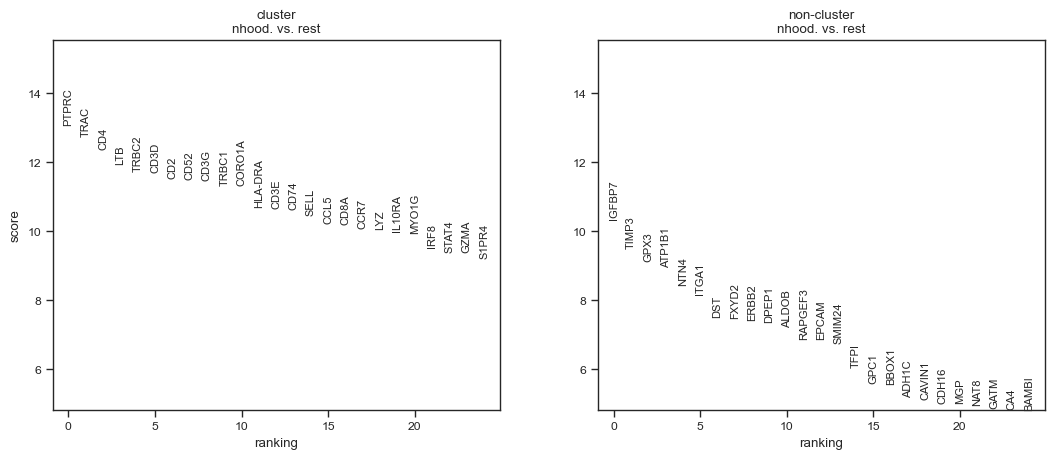

In [26]:
sc.tl.rank_genes_groups(ad_merged, groupby="group", method="wilcoxon")
sc.pl.rank_genes_groups(ad_merged, n_genes=25, show=False)
plt.show()

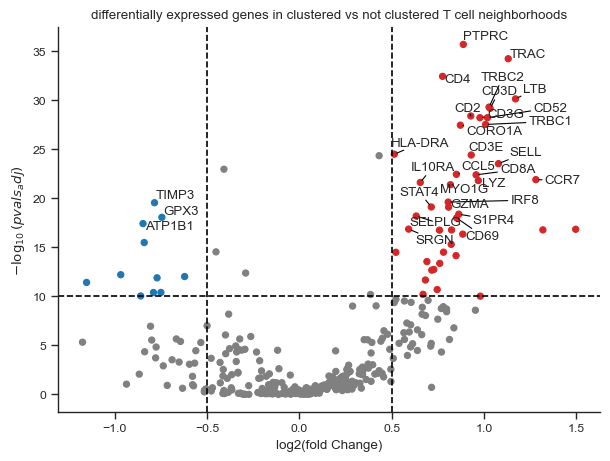

In [27]:
import decoupler as dc

# get dataframe with ranked genes
ranked_genes = sc.get.rank_genes_groups_df(ad_merged, group="cluster\nnhood.")
ranked_genes["pvals_adj"] = ranked_genes["pvals_adj"].clip(lower=1e-300, upper=1)

sns.set_theme(style="ticks", context="paper")
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
dc.pl.volcano(
    ranked_genes.set_index("names"),
    x="logfoldchanges",
    y="pvals_adj",
    thr_stat=0.5,
    thr_sign=1e-10,
    ax=ax,
    top=30,
)
ax.set_xlabel("log2(fold Change)")
ax.set_title(
    "differentially expressed genes in clustered vs not clustered T cell neighborhoods"
)
sns.despine()
plt.savefig(
    os.path.join(figure_dir_2, "volcano_clustered_nhoods_vs_t_nhoods.pdf"),
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)
plt.show()

In [28]:
import gseapy as gp

# NOTE: To speed up, use gp.prerank instead with your own ranked list.
res = gp.gsea(
    data=ad_merged.to_df().T,  # row -> genes, column-> samples
    gene_sets="GO_Biological_Process_2023",
    cls=ad_merged.obs.group,
    permutation_num=1000,
    permutation_type="phenotype",
    outdir=None,
    method="s2n",  # signal_to_noise
    threads=16,
)

In [29]:
for _, row in list(res.res2d.iterrows())[0:10]:
    print(f"{row['Term']}: {row['Lead_genes']}")

T Cell Activation (GO:0042110): PTPRC;TRBC2;CD3D;CD2;TRBC1;CD3G;CD4;CD3E;CD74;CCR7;CD8A
Positive Regulation Of Cytokine Production (GO:0001819): PTPRC;LTB;CD2;CD4;CD74;CCR7;TIGIT;SLAMF1;TYROBP;CCR2;TNF;FCN1;CD274;IL12RB1;FCER1G;CD14;AGER;NOD1;CRTAM;IL23R;XCL1;IL17A
Regulation Of Cytokine Production (GO:0001817): PTPRC;CCR7;IRF8;SRGN;FOXP3;CCR2;TNF;PLD4
Cellular Response To Cytokine Stimulus (GO:0071345): CD4;CCR7;CCL5;SELPLG;IRF8;STAT4;CXCR4;PTPN6;CCR2;STAT1;LILRA4;CCL4
Cytokine-Mediated Signaling Pathway (GO:0019221): CD4;CCL5;CXCL9;STAT4;PTPN6;CCR2;STAT1;TNF;LILRA4;CCL4;IL12RB1;FCER1G;CXCL13;IL23R;XCL2;XCL1;IL17A;CCL2;KIT
Positive Regulation Of ERK1 And ERK2 Cascade (GO:0070374): PTPRC;CD4;CD74;CCR7;CCL5;GPR183;SLAMF1;TNF;CCL4
Inflammatory Response (GO:0006954): LYZ;CCR7;CCL5;CXCL9;CXCR4;CCR2;TNF;CCL4;FUT7;CXCL13;CD14;AGER;NOD1;XCL2;XCL1;CCL2;KIT;IL22;IL1RL1;IFNG;STAT3
Positive Regulation Of Nucleic Acid-Templated Transcription (GO:1903508): CD4;CD74;FOXP3;EOMES;STAT1;TNF
Proteolysis

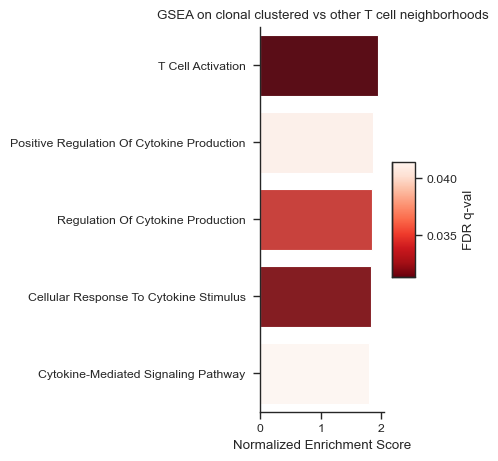

In [30]:
plot_df = res.res2d.copy()
plot_df["Term"] = plot_df["Term"].str.split(r"\(").str[0]
plot_df = plot_df.loc[plot_df["FDR q-val"] < 0.05]
plot_df = plot_df.head(10)

# plot as barplot
sns.set_theme(style="ticks", context="paper")
fig, ax = plt.subplots(1, 1, figsize=(2, 5))

sig_col = "FDR q-val"

sns.barplot(x="NES", y="Term", hue=sig_col, data=plot_df, ax=ax, palette="Reds_r")
ax.get_legend().remove()

norm = plt.Normalize(plot_df[sig_col].min(), plot_df[sig_col].max())
sm = plt.cm.ScalarMappable(cmap="Reds_r", norm=norm)
cbar = plt.colorbar(sm, ax=ax, aspect=5, shrink=0.3, label=sig_col)

ax.set_title("GSEA on clonal clustered vs other T cell neighborhoods")
ax.set_xlabel("Normalized Enrichment Score")
ax.set_ylabel("")
sns.despine()

plt.savefig(
    os.path.join(figure_dir, "gsea_clonal_vs_other_t_nhoods.pdf"),
    dpi=300,
    bbox_inches="tight",
)

plt.show()